UCI Diabetes Dataset Sample:
    Glucose  BloodPressure  SkinThickness  Insulin        BMI  \
0       92             88             55      313  43.695616   
1      166            110             55      515  26.943960   
2      110             81             40      289  22.120967   
3      151             64             23        1  24.369888   
4      137             62             23      504  31.963715   

   DiabetesPedigreeFunction  Age  Outcome  
0                  0.385551   47        0  
1                  1.835800   60        1  
2                  0.795381   51        1  
3                  0.652473   59        1  
4                  0.907329   56        1  

Pima Indians Dataset Sample:
    Glucose  BloodPressure  SkinThickness  Insulin        BMI  \
0      128             69             43      502  47.315389   
1      186             73             55      142  49.449268   
2      134             65             11      233  38.507982   
3      101             78         

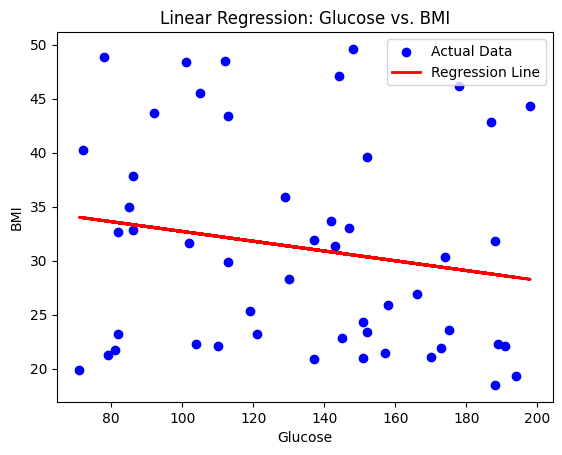


Linear Regression (Predicting BMI using Glucose):
R2 Score: 0.0095


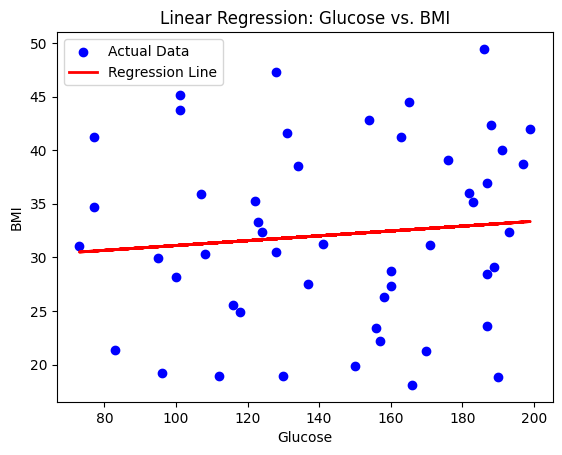


Logistic Regression (Predicting Outcome using ['Glucose', 'BloodPressure', 'BMI', 'Age']):
Accuracy Score: 0.5000

Logistic Regression (Predicting Outcome using ['Glucose', 'BloodPressure', 'BMI', 'Age']):
Accuracy Score: 0.4000


In [18]:
# Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, accuracy_score

# Load the Datasets
uci_diabetes = pd.read_csv("uci_diabetes.csv")
pima_diabetes = pd.read_csv("pima_diabetes.csv")

# Display first few rows
print("UCI Diabetes Dataset Sample:\n", uci_diabetes.head())
print("\nPima Indians Dataset Sample:\n", pima_diabetes.head())

# Perform Linear Regression (Glucose vs. BMI)
def linear_regression_analysis(df, x_column, y_column):
    X = df[[x_column]]  # Independent variable
    Y = df[y_column]  # Dependent variable

    model = LinearRegression()
    model.fit(X, Y)
    Y_pred = model.predict(X)

    r2 = r2_score(Y, Y_pred)

    print(f"\nLinear Regression (Predicting {y_column} using {x_column}):")
    print(f"R2 Score: {r2:.4f}")

    # Plot
    plt.scatter(X, Y, color='blue', label='Actual Data')
    plt.plot(X, Y_pred, color='red', linewidth=2, label='Regression Line')
    plt.xlabel(x_column)
    plt.ylabel(y_column)
    plt.title(f"Linear Regression: {x_column} vs. {y_column}")
    plt.legend()
    plt.show()

# Apply Linear Regression on both datasets
linear_regression_analysis(uci_diabetes, "Glucose", "BMI")
linear_regression_analysis(pima_diabetes, "Glucose", "BMI")

# Perform Logistic Regression (Predicting Diabetes)
def logistic_regression_analysis(df, features, target):
    X = df[features]
    Y = df[target]

    # Splitting dataset
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

    model = LogisticRegression()
    model.fit(X_train, Y_train)
    Y_pred = model.predict(X_test)

    accuracy = accuracy_score(Y_test, Y_pred)
    print(f"\nLogistic Regression (Predicting {target} using {features}):")
    print(f"Accuracy Score: {accuracy:.4f}")

# Select features and target
features = ["Glucose", "BloodPressure", "BMI", "Age"]
target = "Outcome"  # Assuming 'Outcome' represents diabetes presence

# Apply Logistic Regression on both datasets
logistic_regression_analysis(uci_diabetes, features, target)
logistic_regression_analysis(pima_diabetes, features, target)